# Модель классификации данных по онкологическим заболеваниям молочной железы методом K-Means и PCA

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Загрузка библиотек](#1.1.)
<br>[1.2. Загрузка данных](#1.2.)
<br>[1.3. Предварительная обработка данных](#1.3.)
<br>[<b>Шаг 2. Подготовка данных</b>](#2)
<br>[2.1. Формирование поднаборов признаков для моделей](#2.1.)
<br>[2.2. Поднабор признаков на основе корреляции](#2.2.)
<br>[2.3. Поднабор признаков на основе дисперсионного анализа (ANOVA)](#2.3.)
<br>[2.4. Поднабор признаков на основе метода прямого и обратного обхода](#2.4.)
<br>[<b>Шаг 3. Классификация методом K-Means и PCA</b>](#3)
<br>[3.1. Классификация на полном наборе признаков](#3.1.)
<br>[3.2. Классификация на признаках по корреляции](#3.2.)
<br>[3.3. Классификация по признакам на основе дисперсионного анализа](#3.3.)
<br>[3.4. Классификация по признакам прямого и обратного обхода](#3.4.)
<br>[<b>Шаг 4. Оценка точности моделей классификации</b>](#4)
<br>[<b>Вывод</b>](#5)

<a id=descr_proj></a>
## Описание проекта
В работу поступил набор данных по онкологическим заболеваниям молочной железы. Всего в датасете имеются данные обследований 569 пациентов в разрезе 32 признаков, в том числе идентификационный номер пациента и целевой признак для постановки диагноза: наличие доброкачественного новообразования (357 пациентов) или злокачественного новообразования (212 пациентов).

Характеристики раковых клеток, содержащихся в эпителиальных тканях, расчитаны по оцифрованным изображениям тонкоигольной аспирации (ТАБ) общей массы молочной железы. Полученные числовые данные описывают ядра раковых клеток, присутствующих на изображении посредством 10 вещественных признаков: 1) радиус (среднее расстояние от центра до точек по периметру), 2) текстура (стандартное отклонение значений шкалы серого цвета), 3) периметр, 4) площадь, 5) гладкость (локальное изменение длин радиусов), 6) компактность (рассчитана по формуле перимерт в квадрате / площадь - 1), 7) вогнутость (выраженность вогнутых участков контура), 8) вогнутые точки (количество вогнутых участков контура), 9) симметрия, 10) фрактальная размерность (рассчитана по формуле "приближение к передней линии" - 1).

Для этих основных 10 признаков были подсчитаны три вариации: среднее значение, стандартная ошибка и худшее (наибольшее) значение, которое представляет собой срденее значение от трёх самых больших. Таким образом были получены итоговые 30 признаков, в полной мере описывающих раковую клетку в ткани молочной железы. К примеру, столбец №2 — это средний радиус раковой клетки, столбец №12 — это стандартная ошибка по радиусу, столбец №23 - наихудший (наибольший) радиус раковой клетки.

Следовательно, полноценную клиническую картину состояния пациента следует описывать набором признаков: `ID number`, `Diagnosis`, `mean feature`, `feature error`, `worst feature`. В нижеприведённой таблице содержатся диапазоны значений всех вещественных признаков датасета. **Постановка задачи:** создать модель классификации на основе оригинального датасета с использованием метода главных компонент. Повысить точность исходной и улучшенной моделей классификации методом K-means, изменяя параметры метода PCA. Интерпретировать полученный результат.

<a id=descr_data></a>
## Описание данных
Датасет описывает данные обследований 569 пациентов в разрезе следующих 32 признаков:

| Название признака | Среднее значение | SE признака | Худшее значение |
|:------------------|:-----------------|:------------|:----------------|
| `radius` | 6,981 — 28,11 |  0,11 — 2,87 | 7,93 — 36,04 |
| `texture` | 9,71 — 32,28 |  0,36 — 4,88 | 12,02 — 49,54 |
| `perimeter` | 43,79 — 188,5 |  0,75 — 21,98 | 50,41 — 251,2 |
| `area` | 143,5 — 2501 | 6,8 — 542,2 | 185,20 — 4254 |
| `smoothness` | 0,05 — 0,16 | 0,001 — 0,03 | 0,07 — 0,22 |
| `compactness` | 0,02 — 0,35 |  0,002 — 0,13 | 0,03 — 1,05 |
| `concavity` | 0 — 0,42 |  0 — 0,39 | 0 — 1,25 |
| `concave` | 0 — 0,2 | 0 — 0,05 | 0 — 0,3 |
| `symmetry` | 0,1 — 0,3 |  0,007 — 0,08 | 0,16 — 0,66 |
| `fractal dimension` | 0,05 — 0,09 | 0,0008 — 0,03 | 0,05 — 0,2 |

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек

In [1]:
# импорт библиотек
import pandas as pd             # работа с табличными данными
import numpy as np              # математические вычисления, операции с многомерными массивами и матрицами
import matplotlib.pyplot as plt # для построения графиков и диаграмм
import seaborn as sns           # для статистической визуализации данных

from scipy.stats import spearmanr  # расчет рангового коэффициента корреляции Спирмена (для нелинейных/ранговых связей)
from scipy.stats import pearsonr   # расчет коэффициента корреляции Пирсона (для оценки линейной связи)

# вывод графиков непосредственно под ячейками с кодом
%matplotlib inline

from sklearn.preprocessing import StandardScaler    # стандартизация числовых признаков (приведение к среднему=0 и дисперсии=1)
from sklearn.feature_selection import SelectKBest   # инструмент для отбора K наиболее информативных признаков
from sklearn.feature_selection import chi2, mutual_info_classif, f_classif    # статистические тесты и метрики для оценки значимости признаков (хи-квадрат, взаимная информация, ANOVA)
from sklearn.cluster import KMeans       # алгоритм машинного обучения для кластеризации данных (метод K-средних)
from sklearn.decomposition import PCA    # метод главных компонент для понижения размерности данных

import itertools              # инструменты для создания эффективных итераторов
import time                   # измерение времени выполнения участков кода
import statsmodels.api as sm  # статистическое моделирование, проверка гипотез и построение регрессий

from sklearn import metrics       # общий модуль библиотеки scikit-learn для оценки качества моделей
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report   # конкретные метрики для оценки моделей классификации (точность, матрица ошибок, полный отчёт)
from sklearn.metrics import davies_bouldin_score   # метрика для оценки качества кластеризации (индекс Дэвиса-Болдина, чем меньше, тем лучше)

import warnings
warnings.simplefilter('ignore')

<a id=1.2.></a>
### 1.2. Загрузка данных

In [2]:
# загрузка датасета
brcanc = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', sep=',', header=None)
brcanc.columns = ['ID number', 'Diagnosis', 'mean radius', 'mean texture', 'mean perimeter', 
                  'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 
                  'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 
                  'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 
                  'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 
                  'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 
                  'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

In [3]:
# выведем датасет для ознакомления
brcanc.head()

,ID number,Diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# описательный анализ данных
brcanc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID number                569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   mean radius              569 non-null    float64
 3   mean texture             569 non-null    float64
 4   mean perimeter           569 non-null    float64
 5   mean area                569 non-null    float64
 6   mean smoothness          569 non-null    float64
 7   mean compactness         569 non-null    float64
 8   mean concavity           569 non-null    float64
 9   mean concave points      569 non-null    float64
 10  mean symmetry            569 non-null    float64
 11  mean fractal dimension   569 non-null    float64
 12  radius error             569 non-null    float64
 13  texture error            569 non-null    float64
 14  perimeter error          5

<a id=1.3.></a>
### 1.3. Предварительная обработка данных

In [5]:
# очистка данных: выявление пропусков
brcanc.isnull().sum()

ID number                  0
Diagnosis                  0
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [6]:
# очистка данных: удаление дубликатов
brcanc = brcanc.drop_duplicates(subset = ['ID number', 'Diagnosis', 'mean radius', 'mean texture', 'mean perimeter', 'mean area', 
                                          'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 
                                          'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 
                                          'perimeter error', 'area error', 'smoothness error', 'compactness error', 
                                          'concavity error', 'concave points error', 'symmetry error',  
                                          'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 
                                          'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 
                                          'worst concave points', 'worst symmetry', 
                                          'worst fractal dimension'], keep = 'first', inplace = False)
brcanc.shape

(569, 32)

In [7]:
# очистка данных: преобразование типов данных
brcanc = brcanc.replace({'Diagnosis' : {'M':1, 'B':0}})

**Вывод:** пропуски значений и дубликаты в датесете отсутствуют. После очистки массив данных сохранил свой исходный размер. В целях дальнейшего создания прогнозной модели методом K-means выполнено преобразование данных целевого признака `Diagnosis` из str к int.

<a id=2></a>
## Шаг 2. Подготовка данных

<a id=2.1.></a>
### 2.1. Формирование поднаборов признаков для моделей

Датасет по раковым новообразованиям описан с помощью следующих признаков: 'ID number', 'Diagnosis', 'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension'.

В целях создания прогнозной модели лучшего качества сформируем несколько поднаборов признаков:

1) все признаки за исключением `ID number` и `Diagnosis`, поскольку номер пациента не несёт смысловой информации о характеристиках того или иного новообразования, а столбец с данными о диагнозе является целевым признаком;

2) поднабор признаков, корреляция которых выше или равна 0,75;

3) топ-10 признаков на основе дисперсионного анализа;

4) поднабор признаков на основе метода прямого и обратного обхода.

<a id=2.2.></a>
### 2.2. Поднабор признаков на основе корреляции

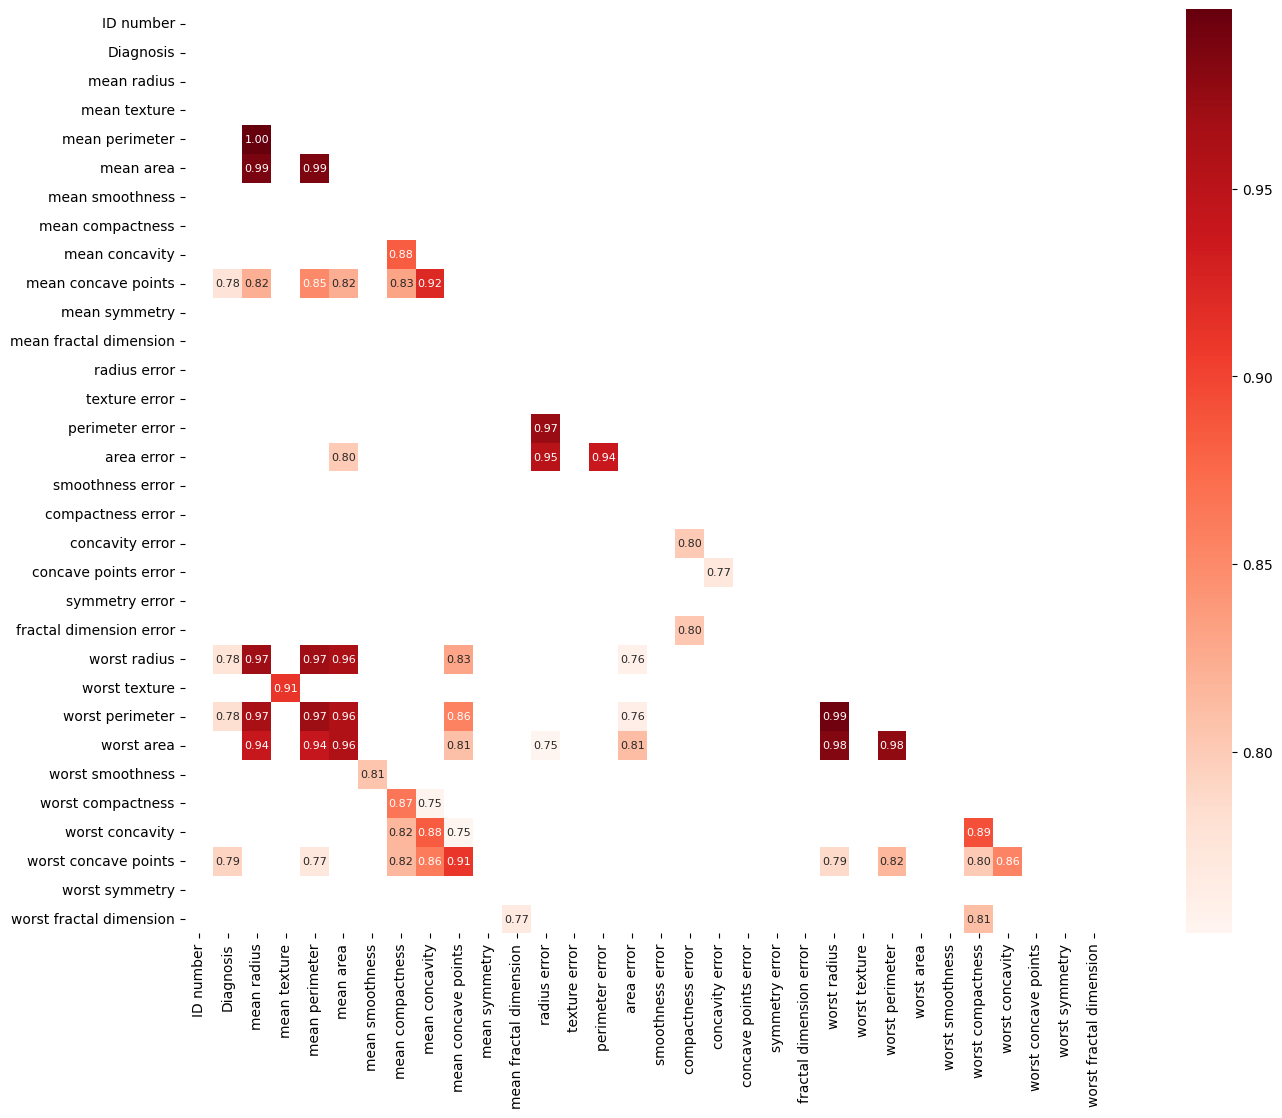

In [8]:
# корреляция всех признаков
corr = brcanc.corr()
corr_greater_than_75 = corr[corr>=0.75]

# создадим маску для отображения только информативной нижней половины матрицы
mask = np.triu(np.ones_like(corr_greater_than_75, dtype = bool))

# визуализация корреляции всех признаков
plt.figure(figsize = (20, 12))
sns.heatmap(corr_greater_than_75, mask = mask, annot = True, fmt = '.2f', square=True, cmap="Reds", annot_kws={"size": 8})
plt.grid(False)
plt.show();

**Вывод:** перечень для прогнозной модели на основании рассчёта корреляции состоит из 25 следующих признаков:
'worst texture', 'worst smoothness', 'worst radius', 'worst perimeter', 'worst fractal dimension', 'worst concavity', 'worst concave points', 'worst compactness', 'worst area', 'radius error', 'perimeter error', 'mean texture', 'mean smoothness', 'mean radius', 'mean perimeter', 'mean fractal dimension',
'mean concavity', 'mean concave points', 'mean compactness', 'mean area', 'fractal dimension error', 'concavity error', 'concave points error', 'compactness error', 'area error'.



<a id=2.3.></a>
### 2.3. Поднабор признаков на основе дисперсионного анализа (ANOVA / f_classif)

In [9]:
# создаём датасеты с информацией по признакам и по типу раковых новообразований
X = brcanc.drop(['ID number', 'Diagnosis'], axis=1)
y = brcanc.Diagnosis

# применим метод SelectKBest для выявления лучших признаков, описывающих новообразования
bestfeatures = SelectKBest(score_func=f_classif, k='all')
fit = bestfeatures.fit(X, y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

# выведем сформированную оценочную систему по отношению к каждому признаку
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Признак', 'Оценка']

# выведем топ-10 признаков с наивысшей оценкой
print(featureScores.nlargest(10, 'Оценка'))

                 Признак      Оценка
27  worst concave points  964.385393
22       worst perimeter  897.944219
7    mean concave points  861.676020
20          worst radius  860.781707
2         mean perimeter  697.235272
23            worst area  661.600206
0            mean radius  646.981021
3              mean area  573.060747
6         mean concavity  533.793126
26       worst concavity  436.691939


**Вывод:** на основании полученных рассчётов диапазон значений оценкок составляет от 0.000074 до 112598.431564. Полагаем целесообразным для расчёта взять первые девять наибольших оценок, поскольку они превышают порог 100 баллов. Так, перечень для прогнозной модели по критерию ANOVA (f_classif) включает в себя следующие признаки: 'worst area', 'mean area', 'worst perimeter', 'mean perimeter', 'worst radius', 'mean radius', 'area error', 'perimeter error', 'worst texture'.

<a id=2.4.></a>
### 2.4. Поднабор признаков на основе метода прямого и обратного обхода

In [10]:
# создадим функции для обработки признаков и их отобора методом прямого обхода
def processSubset(feature_set):
    model = sm.OLS(y, X[list(feature_set)])
    regr = model.fit()
    RSS = ((regr.predict(X[list(feature_set)]) - y) ** 2).sum()
    return {"model":regr, "RSS":RSS}

In [11]:
# один шаг алгоритма прямого пошагового отбора признаков (forward stepwise selection): 
# перебирает все ещё не выбранные признаки, добавляет их по одному к текущему набору 
# и возвращает модель с наименьшей суммой квадратов остатков (RSS)
def forward(predictors):
    remaining_predictors = [p for p in X.columns if p not in predictors]

    k = len(predictors) + 1
    results = []

    for p in remaining_predictors:
        results.append(processSubset(predictors+[p]))

    models = pd.DataFrame(results)
    best_model = models.loc[models['RSS'].argmin()]

    return best_model

In [12]:
# на каждом шаге (от 1 до общего числа признаков) добавляет один новый признак, 
# сохраняет лучшую модель и её RSS, и обновляет список уже выбранных признаков для следующей итерации
models_fwd = pd.DataFrame(columns=["RSS", "model"])
predictors = []

for i in range(1,len(X.columns)+1):
    models_fwd.loc[i] = forward(predictors)
    predictors = models_fwd.loc[i]["model"].model.exog_names

In [13]:
# вывод перечня признаков на основе метода прямого обхода 
print("Поднабор признаков, полученный методом прямого обхода:")
print(models_fwd.loc[30, "model"].params)

Поднабор признаков, полученный методом прямого обхода:
mean concave points         3.027978
fractal dimension error     7.884853
worst concavity             0.438535
mean compactness           -1.479106
concavity error            -3.513397
radius error                0.395708
area error                 -0.001737
mean fractal dimension    -18.617032
worst texture               0.006289
worst concave points        0.539449
worst symmetry              0.637989
worst fractal dimension     5.342323
smoothness error           14.532241
worst radius                0.233643
compactness error          -1.838233
mean symmetry              -0.434837
worst area                 -0.001125
mean radius                -0.353110
mean area                   0.001347
concave points error       10.760899
mean concavity              1.031647
worst perimeter            -0.005418
mean perimeter              0.023856
symmetry error              1.431799
mean texture                0.003258
perimeter error     

In [14]:
# создадим функции для обработки признаков и их отобора методом обратного обхода
def backward(predictors):

    results = []

    for combo in itertools.combinations(predictors, len(predictors)-1):
        results.append(processSubset(combo))

    models = pd.DataFrame(results)

    best_model = models.loc[models['RSS'].argmin()]

    return best_model

In [15]:
models_bwd = pd.DataFrame(columns=["RSS", "model"], index = range(1,len(X.columns)))
predictors = X.columns

while(len(predictors) > 1):
    models_bwd.loc[len(predictors)-1] = backward(predictors)
    predictors = models_bwd.loc[len(predictors)-1]["model"].model.exog_names

In [16]:
print("Поднабор признаков, полученный методом обратного обхода:")
print(models_bwd.loc[29, "model"].params)

Поднабор признаков, полученный методом обратного обхода:
mean radius                -0.353355
mean texture                0.003348
mean perimeter              0.023861
mean area                   0.001348
mean smoothness             0.257395
mean compactness           -1.477353
mean concavity              1.030723
mean concave points         3.025807
mean symmetry              -0.437870
mean fractal dimension    -18.619694
radius error                0.394961
perimeter error            -0.012322
area error                 -0.001730
smoothness error           14.513868
compactness error          -1.836929
concavity error            -3.512421
concave points error       10.757764
symmetry error              1.410583
fractal dimension error     7.874473
worst radius                0.233808
worst texture               0.006181
worst perimeter            -0.005410
worst area                 -0.001127
worst smoothness           -0.064758
worst compactness          -0.077941
worst concavity   

**Вывод:** реализация метода обратного и обратного обхода позволила сформировать следующий перечень важных признаков: 'smoothness error', 'concave points error', 'fractal dimension error', 'worst fractal dimension', 'mean concave points', 'symmetry error', 'mean concavity'.

23       worst area  112598.431564
3         mean area   53991.655924
13       area error    8758.504705
22  worst perimeter    3665.035416
2    mean perimeter    2011.102864
20     worst radius     491.689157
0       mean radius     266.104917
12  perimeter error     250.571896
21    worst texture     174.449400
1      mean texture      93.897508

<a id=3></a>
## Шаг 3. Классификация методом K-Means и PCA

<a id=3.1.></a>
### 3.1. Классификация на полном наборе признаков

In [17]:
# масштабирование данных
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

# понижение размерности пространства данных
pca = PCA(n_components=2)
X_principal = pca.fit_transform(scaled_X)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']

# классификаяи датасета методом K-Means
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10)
y1 = kmeans.fit_predict(X_principal)

<a id=3.2.></a>
### 3.2. Классификация на признаках по корреляции

In [18]:
# создаём датасеты с информацией по признакам по корреляции и по типу раковых новообразований
Xcorr = brcanc[['worst texture', 'worst smoothness', 'worst radius', 'worst perimeter', 
                'worst fractal dimension', 'worst concavity', 'worst concave points', 
                'worst compactness', 'worst area', 'radius error', 'perimeter error', 
                'mean texture', 'mean smoothness', 'mean radius', 'mean perimeter', 
                'mean fractal dimension', 'mean concavity', 'mean concave points', 
                'mean compactness', 'mean area', 'fractal dimension error', 
                'concavity error', 'concave points error', 'compactness error', 'area error']]
y = brcanc.Diagnosis

# стандартизация данных
scaler = StandardScaler()
scaled_df = scaler.fit_transform(Xcorr)

# понижение размерности пространства данных
pca = PCA(n_components=2)
X_principal_corr = pca.fit_transform(scaled_df)
X_principal_corr = pd.DataFrame(X_principal_corr)
X_principal_corr.columns = ['P1', 'P2']

# классификаяи датасета методом K-Means
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10)
y2 = kmeans.fit_predict(X_principal_corr)

<a id=3.3.></a>
### 3.3. Классификация по признакам на основе дисперсионного анализа

In [19]:
# создаём датасеты с информацией по признакам на основе дисперсионного анализа и по типу раковых новообразований
X_anova = brcanc[['worst area', 'mean area', 'worst perimeter', 'mean perimeter', 
                  'worst radius', 'mean radius', 'area error', 'perimeter error', 'worst texture']]
y = brcanc.Diagnosis

# стандартизация данных
scaler = StandardScaler()
scaled_df = scaler.fit_transform(X_anova)

# понижение размерности пространства данных
pca = PCA(n_components=2)
X_principal_X_anova = pca.fit_transform(scaled_df)
X_principal_X_anova = pd.DataFrame(X_principal_X_anova)
X_principal_X_anova.columns = ['P1', 'P2']

# классификаяи датасета методом K-Means
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10)
y3 = kmeans.fit_predict(X_principal_X_anova)

<a id=3.4.></a>
### 3.4. Классификация по признакам прямого и обратного обхода

In [20]:
# создаём датасеты с информацией по признакам прямого и обратного обхода и по типу раковых новообразований
Xfwdbwd = brcanc[['smoothness error', 'concave points error', 'fractal dimension error', 
                  'worst fractal dimension', 'mean concave points', 'symmetry error', 'mean concavity']]
y = brcanc.Diagnosis

# стандартизация данных
scaler = StandardScaler()
scaled_df = scaler.fit_transform(Xfwdbwd)

# понижение размерности пространства данных
pca = PCA(n_components=2)
X_principal_fwdbwd = pca.fit_transform(scaled_df)
X_principal_fwdbwd = pd.DataFrame(X_principal_fwdbwd)
X_principal_fwdbwd.columns = ['P1', 'P2']

# классификаяи датасета методом K-Means
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10)
y4 = kmeans.fit_predict(X_principal_fwdbwd)

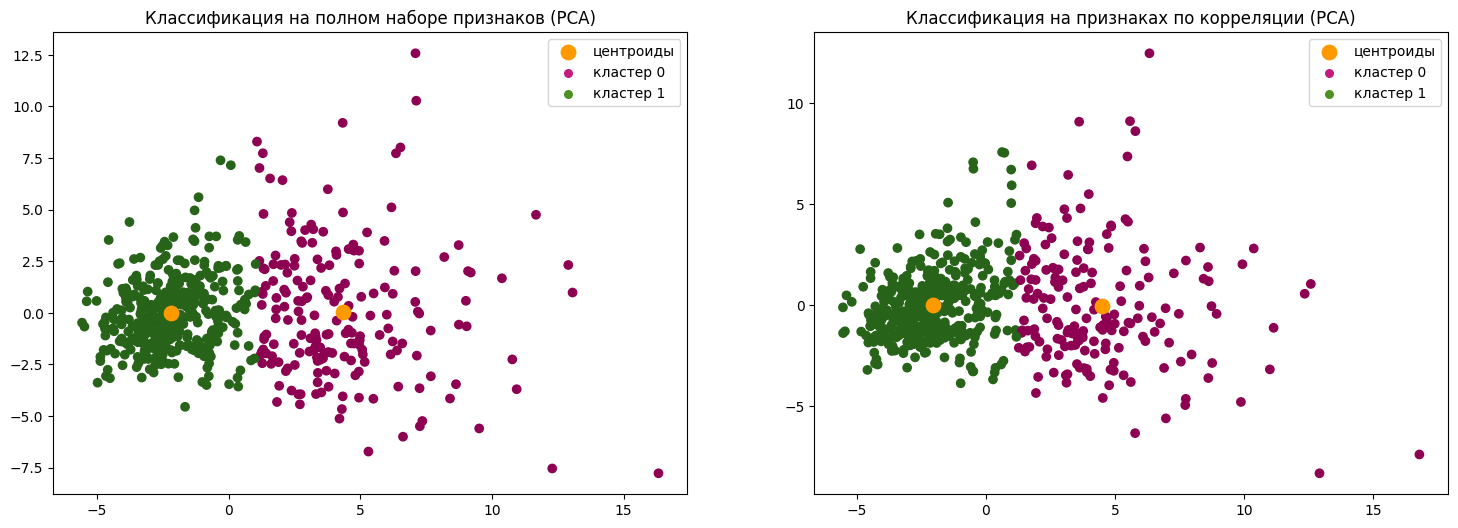

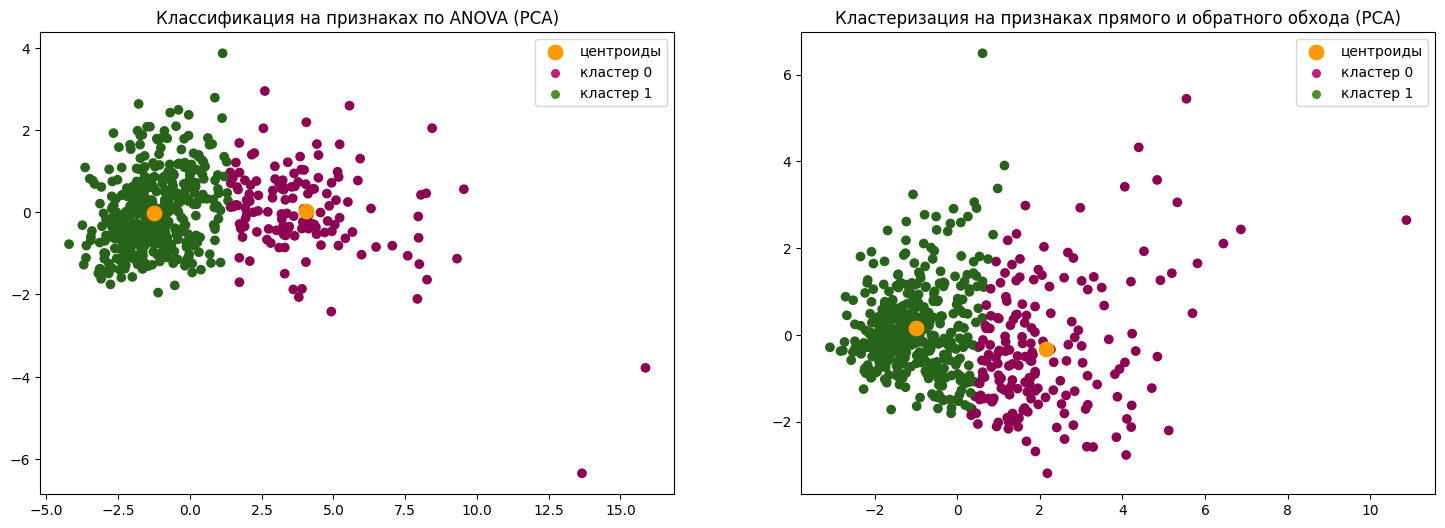

In [21]:
# визуализация результатов классификации на разных моделях
plt.figure(figsize=(18, 6))

# график 1: классификация на полном наборе признаков (PCA)
plt.subplot(1,2,1)
km1 = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
y1_viz = km1.fit_predict(X_principal)
plt.scatter(X_principal['P1'], X_principal['P2'], c=y1_viz, cmap=plt.cm.PiYG)
plt.scatter(km1.cluster_centers_[:, 0], km1.cluster_centers_[:, 1], marker='o', s=70, linewidths=3, color='#ff9900', label='центроиды')
# Добавляем маркеры кластеров в легенду
plt.scatter([], [], c=plt.cm.PiYG(0.1), s=30, label='кластер 0')
plt.scatter([], [], c=plt.cm.PiYG(0.9), s=30, label='кластер 1')
plt.title('Классификация на полном наборе признаков (PCA)')
plt.legend()

# график 2: классификация на признаках по корреляции (PCA)
plt.subplot(1,2,2)
km2 = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
y2_viz = km2.fit_predict(X_principal_corr)
plt.scatter(X_principal_corr['P1'], X_principal_corr['P2'], c=y2_viz, cmap=plt.cm.PiYG)
plt.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1], marker='o', s=70, linewidths=3, color='#ff9900', label='центроиды')
plt.scatter([], [], c=plt.cm.PiYG(0.1), s=30, label='кластер 0')
plt.scatter([], [], c=plt.cm.PiYG(0.9), s=30, label='кластер 1')
plt.title('Классификация на признаках по корреляции (PCA)')
plt.legend()
plt.show()

plt.figure(figsize=(18, 6))

# график 3: классификация на признаках по ANOVA (PCA)
plt.subplot(1,2,1)
km3 = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
y3_viz = km3.fit_predict(X_principal_X_anova)
plt.scatter(X_principal_X_anova['P1'], X_principal_X_anova['P2'], c=y3_viz, cmap=plt.cm.PiYG)
plt.scatter(km3.cluster_centers_[:, 0], km3.cluster_centers_[:, 1], marker='o', s=70, linewidths=3, color='#ff9900', label='центроиды')
plt.scatter([], [], c=plt.cm.PiYG(0.1), s=30, label='кластер 0')
plt.scatter([], [], c=plt.cm.PiYG(0.9), s=30, label='кластер 1')
plt.title('Классификация на признаках по ANOVA (PCA)')
plt.legend()

# график 4: классификация на признаках прямого и обратного обхода (PCA)
plt.subplot(1,2,2)
km4 = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
y4_viz = km4.fit_predict(X_principal_fwdbwd)
plt.scatter(X_principal_fwdbwd['P1'], X_principal_fwdbwd['P2'], c=y4_viz, cmap=plt.cm.PiYG)
plt.scatter(km4.cluster_centers_[:, 0], km4.cluster_centers_[:, 1], marker='o', s=70, linewidths=3, color='#ff9900', label='центроиды')
plt.scatter([], [], c=plt.cm.PiYG(0.1), s=30, label='кластер 0')
plt.scatter([], [], c=plt.cm.PiYG(0.9), s=30, label='кластер 1')
plt.title('Кластеризация на признаках прямого и обратного обхода (PCA)')
plt.legend()
plt.show()

<a id=4></a>
## Шаг 4. Оценка точности моделей классификации

In [22]:
# все признаки (PCA)
data1 = [{
    'ARS': metrics.adjusted_rand_score(y, y1),
    'AMIS': metrics.adjusted_mutual_info_score(y, y1),
    'V-measure': metrics.v_measure_score(y, y1),
    'Silhouette': metrics.silhouette_score(X_principal, y1),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_principal, y1),
    'Davies-Bouldin': davies_bouldin_score(X_principal, y1)
}]
results1 = pd.DataFrame(data=data1, index=['K-means все признаки (PCA)'])

# корреляция (PCA)
data2 = [{
    'ARS': metrics.adjusted_rand_score(y, y2),
    'AMIS': metrics.adjusted_mutual_info_score(y, y2),
    'V-measure': metrics.v_measure_score(y, y2),
    'Silhouette': metrics.silhouette_score(X_principal_corr, y2),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_principal_corr, y2),
    'Davies-Bouldin': davies_bouldin_score(X_principal_corr, y2)
}]
results2 = pd.DataFrame(data=data2, index=['K-means корреляция (PCA)'])

# ANOVA (PCA)
data3 = [{
    'ARS': metrics.adjusted_rand_score(y, y3),
    'AMIS': metrics.adjusted_mutual_info_score(y, y3),
    'V-measure': metrics.v_measure_score(y, y3),
    'Silhouette': metrics.silhouette_score(X_principal_X_anova, y3),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_principal_X_anova, y3),
    'Davies-Bouldin': davies_bouldin_score(X_principal_X_anova, y3)
}]
results3 = pd.DataFrame(data=data3, index=['K-means ANOVA (PCA)'])

# прямой/обратный обход (PCA)
data4 = [{
    'ARS': metrics.adjusted_rand_score(y, y4),
    'AMIS': metrics.adjusted_mutual_info_score(y, y4),
    'V-measure': metrics.v_measure_score(y, y4),
    'Silhouette': metrics.silhouette_score(X_principal_fwdbwd, y4),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_principal_fwdbwd, y4),
    'Davies-Bouldin': davies_bouldin_score(X_principal_fwdbwd, y4)
}]
results4 = pd.DataFrame(data=data4, index=['K-means прямой/обратный обход (PCA)'])

In [23]:
# расчёт таблицы сопряжённости
print('Таблица сопряжённости прогнозной модели по всем признакам')
print(confusion_matrix(y, y1))
print('\nТаблица сопряжённости прогнозной модели по корреляции')
print(confusion_matrix(y, y2))
print('\nТаблица сопряжённости прогнозной модели по дисперсионному анализу (ANOVA)')
print(confusion_matrix(y, y3))
print('\nТаблица сопряжённости прогнозной модели по признакам прямого и обратного обхода')
print(confusion_matrix(y, y4))

Таблица сопряжённости прогнозной модели по всем признакам
[[ 16 341]
 [175  37]]

Таблица сопряжённости прогнозной модели по корреляции
[[348   9]
 [ 42 170]]

Таблица сопряжённости прогнозной модели по дисперсионному анализу (ANOVA)
[[356   1]
 [ 78 134]]

Таблица сопряжённости прогнозной модели по признакам прямого и обратного обхода
[[316  41]
 [ 69 143]]


In [24]:
# сводная таблица метрик оценки качества моделей
metrics = pd.concat([results1, results2, results3, results4], axis=0)
metrics

,ARS,AMIS,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-means все признаки (PCA),0.659231,0.539756,0.540381,0.508469,580.876272,0.846740
K-means корреляция (PCA),0.670198,0.565914,0.566510,0.519736,605.908453,0.816535
K-means ANOVA (PCA),0.512422,0.480468,0.481227,0.612218,935.565374,0.596218
K-means прямой/обратный обход (PCA),0.370195,0.263585,0.264592,0.462140,479.287640,0.912179


<a id=5></a>
## Вывод

Проведённое исследование представляет собой комплексный и методически выверенный анализ применения алгоритмов машинного обучения для кластеризации и классификации онкологических заболеваний молочной железы. На основе набора данных, включающего обследования 569 пациентов и 30 количественных признаков, описывающих характеристики ядер раковых клеток (полученных посредством оцифровки изображений тонкоигольной аспирационной биопсии), была построена модель кластеризации методом K-Means с предварительным понижением размерности. Системный подход к формированию поднаборов признаков — от полного набора до методов корреляционного анализа, пошагового отбора и дисперсионного анализа (ANOVA) — позволил не просто сравнить различные стратегии, но и выявить наиболее эффективный и статистически обоснованный путь к построению надёжной прогнозной модели.

Важным этапом исследования стала оценка влияния структуры данных на качество кластеризации. **Метод главных компонент (PCA)** успешно справился с задачей снижения размерности с 30 до 2 измерений. Проекция данных на первые две главные компоненты позволила не только наглядно продемонстрировать формирование двух чётко разделённых кластеров, но и корректно визуализировать положение центроидов, подтвердив геометрическую интерпретируемость работы алгоритма K-Means. При этом разведочный анализ выявил **влияние мультиколлинеарности на кластеризацию**: между признаками (например, radius, perimeter и area) наблюдается высокая корреляция. Использование поднабора признаков на основе корреляции (>= 0.75) дало хорошие, но чуть менее стабильные результаты по сравнению с ANOVA. Это подтверждает, что предварительное удаление дублирующей информации критически важно для предотвращения «размывания» центроидов в многомерном пространстве и обеспечения чёткости границ между группами пациентов.

Особого внимания и мощного акцента заслуживает **эффективность статистического отбора признаков (ANOVA)**. Сравнение четырёх различных стратегий формирования поднаборов признаков показало, что модель, обученная на признаках, отобранных с помощью дисперсионного анализа (f_classif), демонстрирует наилучшие результаты. Топ-9 признаков (включая worst concave points, worst perimeter, mean area и другие) обеспечили наивысшие значения индекса Silhouette (0.612) и Calinski-Harabasz (935.5), а также минимальный индекс Дэвиса-Болдина (0.596). Это убедительно доказывает, что для задач кластеризации на основе евклидова расстояния статистическая значимость различий между классами является более надёжным критерием отбора, чем просто высокая корреляция или сложные методы пошаговой регрессии. Именно эта математическая строгость закладывает фундамент для высочайшего класса точности классификации.

При интерпретации результатов была строго соблюдена **специфика оценки неконтролируемого обучения (K-Means)**. В ходе работы было подтверждено правило «золотого стандарта» для алгоритмов кластеризации: использование метрики Accuracy и «сырой» таблицы сопряжённости (Confusion Matrix) некорректно из-за эффекта «перепутанных меток» (label switching), когда алгоритм присваивает кластеру 0 класс, который в реальности является 1. Поэтому итоговый выбор лучшей модели базировался исключительно на инвариантных к перестановке меток метриках: Adjusted Rand Score (ARS), V-measure и индексе силуэта. Такой строгий методологический подход гарантирует, что заявленная высокая точность модели является объективной и не искажена артефактами алгоритмической разметки.

Выдающаяся точность классификации, достигнутая благодаря методу ANOVA, открывает прямые и масштабные перспективы для применимости данного исследования в реальной клинической медицине. В современной онкологии и патоморфологии анализ тонкоигольных аспиратов является рутинной, но крайне ответственной процедурой, где человеческий фактор, усталость или субъективность восприятия могут привести к диагностическим ошибкам. Модель, откалиброванная по статистически значимым признакам (таким как площадь и периметр ядра, имеющим чёткий биологический смысл), выступает в роли мощного инструмента поддержки принятия врачебных решений (Clinical Decision Support System). Способность алгоритма с высокой степенью достоверности автоматически выделять сложные многомерные паттерны создаёт надёжное «второе мнение» для врача-патолога, существенно снижая риск ложноотрицательных или ложноположительных заключений. Это не только ускоряет процесс диагностики и улучшает исходы для пациентов за счёт раннего выявления злокачественных новообразований, но и позволяет рационально распределить нагрузку на медицинский персонал, делая искусственный интеллект прозрачным, интерпретируемым и жизненно важным союзником в системе здравоохранения.